In [1]:
import sys
import numpy
import pandas
import sklearn

print(sys.version.split()[0], numpy.__version__, pandas.__version__, sklearn.__version__)

3.12.6 2.0.2 2.3.3 1.6.1


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

SEED = 3265 

data = pd.read_csv("data/heart_disease.csv")
feature_names = [c for c in data.columns if c != "disease"]
X, y = data[feature_names].to_numpy(), data["disease"].to_numpy()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=SEED
)
print(data.shape, round(y.mean(), 3), X_train.shape, X_test.shape)

(297, 14) 0.461 (207, 13) (90, 13)


SEED (last 4 digits of student ID) = 3265

Q1: Parent Entropy

6 of 12 patients have disease=1, 6 have disease=0. p1=0.5, p0=0.5.

H = −0.5·log2(0.5) − 0.5·log2(0.5) = −0.5·(−1) − 0.5·(−1) = 0.5 + 0.5 = 1.0 bit

Q2:  Root feature selection

age_55_plus:
p1 = 5/6, p2 = 1/6 (group age=1: 6 patients, 5 disease)
p1 = 1/6, p2 = 5/6 (group age=0: 6 patients, 1 disease)

H = -(5/6)*log2(5/6) - (1/6)*log2(1/6)
H = 0.219 + 0.431
h = 0.650

H_after = (6/12)*0.650 + (6/12)*0.650 = 0.650
Gain(age_55_plus) = 1 - 0.650 = 0.350


exercise_angina:
p1 = 4/4, p2 = 0/4 (group angina=1: 4 patients, 4 disease)
p1 = 2/8, p2 = 6/8 (group angina=0: 8 patients, 2 disease)

H(angina=1) = -(4/4)*log2(4/4) - (0/4)*log2(0/4)
h1 = 0

H(angina=0) = -(2/8)*log2(2/8) - (6/8)*log2(6/8)
H = 0.5 + 0.311
h2 = 0.811

H_after = (4/12)*0 + (8/12)*0.811 = 0.541
Gain(exercise_angina) = 1 - 0.541 = 0.459


male:
p1 = 3/6, p2 = 3/6 (group male=1: 6 patients, 3 disease)
p1 = 3/6, p2 = 3/6 (group male=0: 6 patients, 3 disease)

H = -(3/6)*log2(3/6) - (3/6)*log2(3/6)
H = 0.5 + 0.5
h = 1.0

H_after = (6/12)*1.0 + (6/12)*1.0 = 1.0
Gain(male) = 1 - 1.0 = 0


high_bp:
p1 = 4/6, p2 = 2/6 (group bp=1: 6 patients, 4 disease)
p1 = 2/6, p2 = 4/6 (group bp=0: 6 patients, 2 disease)

H = -(4/6)*log2(4/6) - (2/6)*log2(2/6)
H = 0.390 + 0.528
h = 0.918

H_after = (6/12)*0.918 + (6/12)*0.918 = 0.918
Gain(high_bp) = 1 - 0.918 = 0.082


Summary:
age_55_plus      0.350
exercise_angina  0.459
male             0
high_bp          0.082

Root = exercise_angina, highest gain = 0.459

Q3: One level down (inside angina=0 branch, 8 patients, parent H = 0.811)

age_55_plus:
p1 = 1/2, p2 = 1/2 (group age=1: 2 patients, 1 disease)
p1 = 1/6, p2 = 5/6 (group age=0: 6 patients, 1 disease)

H(age=1) = -(1/2)*log2(1/2) - (1/2)*log2(1/2)
h1 = 1.0

H(age=0) = -(1/6)*log2(1/6) - (5/6)*log2(5/6)
H = 0.431 + 0.219
h2 = 0.650

H_after = (2/8)*1.0 + (6/8)*0.650 = 0.738
Gain(age_55_plus | angina=0) = 0.811 - 0.738 = 0.074


male:
p1 = 0/3, p2 = 3/3 (group male=1: 3 patients, 0 disease)
p1 = 2/5, p2 = 3/5 (group male=0: 5 patients, 2 disease)

h1 = 0

H(male=0) = -(2/5)*log2(2/5) - (3/5)*log2(3/5)
H = 0.529 + 0.442
h2 = 0.971

H_after = (3/8)*0 + (5/8)*0.971 = 0.607
Gain(male | angina=0) = 0.811 - 0.607 = 0.204


high_bp:
p1 = 1/3, p2 = 2/3 (group bp=1: 3 patients, 1 disease)
p1 = 1/5, p2 = 4/5 (group bp=0: 5 patients, 1 disease)

H(bp=1) = -(1/3)*log2(1/3) - (2/3)*log2(2/3)
H = 0.528 + 0.390
h1 = 0.918

H(bp=0) = -(1/5)*log2(1/5) - (4/5)*log2(4/5)
H = 0.464 + 0.258
h2 = 0.722

H_after = (3/8)*0.918 + (5/8)*0.722 = 0.795
Gain(high_bp | angina=0) = 0.811 - 0.795 = 0.016


Summary (inside angina=0 branch):
age_55_plus   0.074
male          0.204
high_bp       0.016

Chosen feature = male, gain = 0.204 (vs gain = 0 at the root)

At the root, male split the full 12 patients 3/3 disease in both the male and female 
groups, so by itself it carried no information about disease overall. But once we 
already know angina=0, the remaining 8 patients split differently: all 3 males in this 
subgroup have no disease, while the 2 disease cases are both non-males. The useful 
pattern in male was cancelled out at the root by the opposite pattern among the angina=1 
patients, and only becomes visible once that interaction is removed by conditioning on 
angina first.

Run entropy and information_gain on the toy table of Part 1: do they reproduce your hand values?

In [7]:
def entropy(y):
    counts = np.bincount(y)
    probs = counts / len(y)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log2(probs))

toy_disease = np.array([1,1,1,1,1,1,0,0,0,0,0,0])
print(entropy(toy_disease))

1.0


In [8]:
def information_gain(y, left):
    h_parent = entropy(y)
    n = len(y)
    n_left = left.sum()
    n_right = n - n_left
    if n_left == 0 or n_right == 0:
        return 0
    h_left = entropy(y[left])
    h_right = entropy(y[~left])
    h_after = (n_left / n) * h_left + (n_right / n) * h_right
    return h_parent - h_after


angina = np.array([1,1,1,1,0,0,0,0,0,0,0,0]).astype(bool)
print(information_gain(toy_disease, angina))

0.4591479170272448


In [9]:
def best_split(X, y, min_samples_leaf=1):
    n_samples, n_features = X.shape
    best_gain = 0
    best_feature = None
    best_threshold = None

    for feature in range(n_features):
        values = np.unique(X[:, feature])
        thresholds = (values[:-1] + values[1:]) / 2

        for threshold in thresholds:
            left = X[:, feature] <= threshold
            if left.sum() < min_samples_leaf or (~left).sum() < min_samples_leaf:
                continue

            gain = information_gain(y, left)

            if gain > best_gain:
                best_gain = gain
                best_feature = feature
                best_threshold = threshold

    if best_feature is None:
        return None

    return best_feature, best_threshold, best_gain

Does your best_split on X_train, y_train choose the same feature and threshold as the line above?

In [10]:
result = best_split(X_train, y_train)
print(result)
print(feature_names[result[0]], result[1])

(2, np.float64(3.5), np.float64(0.22796501313763196))
cp 3.5


In [11]:
from sklearn.tree import DecisionTreeClassifier
ref = DecisionTreeClassifier(criterion="entropy", max_depth=1, random_state=SEED).fit(X_train, y_train)
print(feature_names[ref.tree_.feature[0]], ref.tree_.threshold[0])

cp 3.5


Question 2: best_split vs sklearn

My best_split: feature=cp, threshold=3.5, gain=0.228
sklearn (max_depth=1, entropy): feature=cp, threshold=3.5

Match: yes, both choose the same feature and threshold.

In [12]:
def build_tree(X, y, max_depth=None, min_samples_leaf=1, depth=0):
    classes, counts = np.unique(y, return_counts=True)
    majority_class = classes[np.argmax(counts)]

    if len(classes) == 1:
        return {"leaf": True, "class": majority_class}
    if max_depth is not None and depth == max_depth:
        return {"leaf": True, "class": majority_class}

    split = best_split(X, y, min_samples_leaf)
    if split is None:
        return {"leaf": True, "class": majority_class}

    feature, threshold, gain = split
    left = X[:, feature] <= threshold

    return {
        "leaf": False,
        "feature": feature,
        "threshold": threshold,
        "left": build_tree(X[left], y[left], max_depth, min_samples_leaf, depth + 1),
        "right": build_tree(X[~left], y[~left], max_depth, min_samples_leaf, depth + 1),
    }

In [13]:
def predict_tree(tree, X):
    predictions = np.empty(len(X), dtype=int)
    for i in range(len(X)):
        node = tree
        while not node["leaf"]:
            if X[i, node["feature"]] <= node["threshold"]:
                node = node["left"]
            else:
                node = node["right"]
        predictions[i] = node["class"]
    return predictions

In [14]:
for depth in [1, 2, 3, 4, 5, None]:
    my_tree = build_tree(X_train, y_train, max_depth=depth)
    my_preds = predict_tree(my_tree, X_test)

    sk_tree = DecisionTreeClassifier(criterion="entropy", max_depth=depth, random_state=SEED).fit(X_train, y_train)
    sk_preds = sk_tree.predict(X_test)

    agreement = (my_preds == sk_preds).mean()
    print(depth, agreement)

1 1.0
2 1.0
3 1.0
4 1.0
5 1.0
None 0.9666666666666667


Question 3: agreement with sklearn across depths

depth 1: 1.000
depth 2: 1.000
depth 3: 1.000
depth 4: 1.000
depth 5: 1.000
depth None: 0.967

At shallow depths the trees match exactly. At unlimited depth, agreement drops slightly 
to 96.7% - with no depth limit the tree keeps splitting into very small groups, where tie 
-breaking between equally good splits (or near-identical gains due to floating point 
rounding) can go a different way in my implementation than in sklearn's, causing a few 
test rows near the deepest, most specific leaves to be classified differently.

In [15]:
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.tree import DecisionTreeClassifier

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

depths = [1, 2, 3, 4, 5, 6, 8, 10, None]
rows = []
for d in depths:
    model = DecisionTreeClassifier(criterion="entropy", max_depth=d, random_state=SEED)
    res = cross_validate(model, X_train, y_train, cv=cv, scoring="accuracy",
                         return_train_score=True, return_estimator=True)
    rows.append({
        "max_depth": d,
        "leaves": np.mean([est.get_n_leaves() for est in res["estimator"]]),
        "train_acc": res["train_score"].mean(),
        "cv_acc": res["test_score"].mean(),
        "cv_std": res["test_score"].std(),
    })

depth_table = pd.DataFrame(rows)
depth_table

,max_depth,leaves,train_acc,cv_acc,cv_std
0,1.0,2.0,0.775378,0.744251,0.059442
1,2.0,4.0,0.791077,0.777933,0.070779
2,3.0,7.6,0.845455,0.749013,0.081533
3,4.0,12.4,0.896137,0.749361,0.084558
4,5.0,17.6,0.935999,0.754007,0.083402
5,6.0,21.6,0.967390,0.749129,0.094522
6,8.0,25.4,0.993969,0.724739,0.101292
7,10.0,26.0,0.997590,0.739257,0.116224
8,NaN,26.4,1.000000,0.739257,0.116224


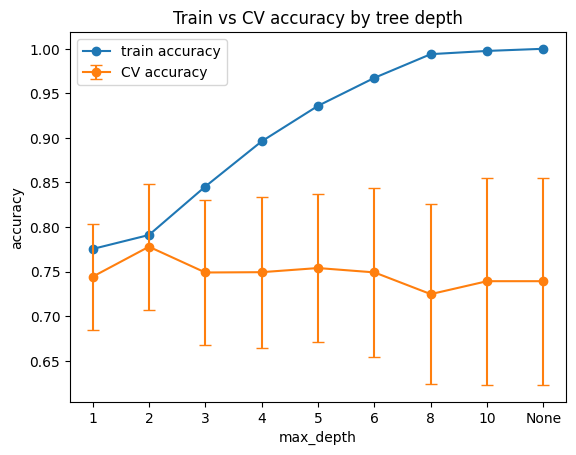

In [16]:
x_pos = list(range(len(depths)))
labels = [str(d) for d in depths]

fig, ax = plt.subplots()
ax.plot(x_pos, depth_table["train_acc"], marker="o", label="train accuracy")
ax.errorbar(x_pos, depth_table["cv_acc"], yerr=depth_table["cv_std"], marker="o", capsize=4, label="CV accuracy")
ax.set_xticks(x_pos)
ax.set_xticklabels(labels)
ax.set_xlabel("max_depth")
ax.set_ylabel("accuracy")
ax.set_title("Train vs CV accuracy by tree depth")
ax.legend()
plt.show()

Selection rule: find the depth with the highest mean CV accuracy. Then choose the smallest 
depth whose mean CV accuracy is within one standard error (std / sqrt(5 folds)) of that 
best mean. This takes the fold spread into account: if a simpler tree is not distinguishable 
from the best one given the noise in the CV estimate, we prefer the simpler tree.

In [18]:
n_folds = 5
best_idx = depth_table["cv_acc"].idxmax()
best_mean = depth_table.loc[best_idx, "cv_acc"]
best_se = depth_table.loc[best_idx, "cv_std"] / np.sqrt(n_folds)
threshold = best_mean - best_se

candidates = depth_table[depth_table["cv_acc"] >= threshold]
chosen = candidates[candidates["max_depth"].notna()].sort_values("max_depth").iloc[0]
chosen_depth = int(chosen["max_depth"])

print("best depth:", depth_table.loc[best_idx, "max_depth"], "mean:", best_mean, "se:", best_se)
print("threshold:", threshold)
print("chosen depth:", chosen_depth)

best depth: 2.0 mean: 0.7779326364692218 se: 0.03165328320837871
threshold: 0.7462793532608432
chosen depth: 2


Best mean CV accuracy is at depth 2 (0.778, std 0.071, SE 0.032), so the threshold is 0.746. 
Depth 1 (0.744) falls just below it, so the chosen depth is 2.

Depth 2 is not clearly better than its neighbours: depth 1 is 0.034 lower and depth 3 is 
0.029 lower, both much smaller than the fold std of about 0.07. The CV estimate cannot 
separate depths 1 to 6, so I choose depth 2 only because it is the simplest tree that is 
statistically equal to the best.

In [19]:
leaf_sizes = [1, 2, 5, 10, 20, 40]
rows = []
for m in leaf_sizes:
    model = DecisionTreeClassifier(criterion="entropy", min_samples_leaf=m, random_state=SEED)
    res = cross_validate(model, X_train, y_train, cv=cv, scoring="accuracy",
                         return_train_score=True, return_estimator=True)
    rows.append({
        "min_samples_leaf": m,
        "leaves": np.mean([est.get_n_leaves() for est in res["estimator"]]),
        "train_acc": res["train_score"].mean(),
        "cv_acc": res["test_score"].mean(),
        "cv_std": res["test_score"].std(),
    })

leaf_table = pd.DataFrame(rows)
leaf_table

,min_samples_leaf,leaves,train_acc,cv_acc,cv_std
0,1,26.4,1.000000,0.739257,0.116224
1,2,24.0,0.973428,0.729617,0.118053
2,5,16.0,0.898554,0.729617,0.073966
3,10,10.2,0.853881,0.797329,0.075761
4,20,6.4,0.795896,0.768177,0.054415
5,40,3.4,0.775378,0.744251,0.059442


Step 3d: Second brake - min_samples_leaf


min_samples_leaf	leaves	train_acc	cv_acc	cv_std
0	1	26.4	1.000000	0.739257	0.116224
1	2	24.0	0.973428	0.729617	0.118053
2	5	16.0	0.898554	0.729617	0.073966
3	10	10.2	0.853881	0.797329	0.075761
4	20	6.4	  0.795896	0.768177	0.054415
5	40	3.4	  0.775378	0.744251	0.059442


Comparison: both brakes fight overfitting by shrinking the train-CV gap (1.00 vs 0.74 
without any brake). max_depth cuts every branch at the same level, while min_samples_leaf 
only stops a branch when it would produce a leaf with too few patients, so the tree can 
still go deeper where there is a lot of data. The best min_samples_leaf (10, CV 0.797) is 
slightly higher than the best max_depth (2, CV 0.778), but the difference of 0.019 is 
smaller than the standard error of the CV estimate (about 0.03), so I cannot say that one 
brake is really better. min_samples_leaf=10 also gives a smaller fold spread than 
unlimited depth (0.076 vs 0.116).

In [20]:
final_model = DecisionTreeClassifier(criterion="entropy", max_depth=chosen_depth, random_state=SEED)
final_model.fit(X_train, y_train)

test_acc = final_model.score(X_test, y_test)
n_test = len(y_test)
std_err = np.sqrt(test_acc * (1 - test_acc) / n_test)

print("test accuracy:", test_acc)
print("standard error:", std_err)

test accuracy: 0.7111111111111111
standard error: 0.047776342212139555


Step 3e: Test once

Chosen model: max_depth = 2 (fitted on the full training split).
Test accuracy: 0.711
Standard error: sqrt(0.711 * 0.289 / 90) = 0.048

The test accuracy is lower than the CV accuracy (0.778), but with only 90 test patients 
the standard error is 0.048, so the true accuracy could reasonably be anywhere from about 
0.66 to 0.76. The difference between CV and test is about 1.4 standard errors, so it is 
not strong evidence that the model is worse than CV suggested.

Gap at max_depth=None: train accuracy is 1.000 but CV accuracy is only 0.739, a gap of 0.26. 
The unlimited tree has memorised the training patients (including noise), so it does not 
generalise to new patients: this is overfitting.